# &nbsp;&nbsp;&nbsp;&nbsp;<span style="color: #1387abff;">Chapter 2: </span>模型学习中的技巧

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;如你所见，我们的全连接神经网络还存在巨大的优化空间。为了填补这些缺陷，本章将重点向你介绍一些可以提升模型表现的方法。让我们开始吧。

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color: #dab70aff;">2.1 优化器的选择</span>

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;所谓模型的学习，其实就是各层参数矩阵更新以降低损失函数值的过程，而这个过程自然也存在众多不同的进行方式。我们在第一章中的方法是：在总训练数据集中随机选取一小批数据，输入模型计算损失函数值，每个参数再向自身梯度的反方向更新( 实际上梯度可以理解为多维的单变量导函数，因此梯度的反方向就是使损失函数值变小的更新方向 )，重复这个选取某批数据的过程。以上方法被称为mini-batch-SGD( stochastic gradient descent )，即随机梯度下降算法。随机梯度下降算法很优秀且有效，但也存在很大的局限性。

In [1]:
import numpy as np
class SGD:
    def __init__(self,learning_rate):
        self.learning_rate = learning_rate
        
    def update(self,params,grads):
        for key in params.keys():
            params[key] -= self.learning_rate*grads[key]

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;想象这样的过程：在群山中寻找最低的山谷，我们往往会往低处走，这就是往梯度反方向行走的过程。然而，如果存在众多不同的山谷，我们很有可能陷入其中某一个而无法寻找真正最低的山谷；如果我们是巨人或者小矮人，则向梯度反方向迈出的一步会非常巨大或者非常微小，分别导致我们错过山谷和花费超长时间搜索山谷；而如果下山的路是盘山公路，向低处前进的方向往往并不是指向最低点。这些妙趣横生的比喻，分别对应了局部最优值不是全局最优值，对学习率过于敏感与梯度下降方向不严格指向极小值点的问题。以上都是SGD方法的缺陷。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;为了一定程度逃离这些困境，我们发明了Momentum方法。依旧是群山中的探险家，但这次我们考虑在一个斜坡上的受力情况，把我们推向梯度反方向的力会给予我们加速度，而在速度变化的过程中也存在空气阻力阻挡我们。因此我们这样模拟这件事：参数矩阵根据我们的速度更新，而速度则是上一刻速度乘上一个动量系数再减去梯度乘学习率。多说反而会有些让人迷惑，请看我们的实践。

\begin{aligned}
v_t &= \gamma v_{t-1} + \eta \nabla_\theta J(\theta_{t-1}) \\
\theta_t &= \theta_{t-1} - v_t
\end{aligned}

In [2]:
class Momentum:
    def __init__(self,lr, momentum):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self,params,grads):
        if self.v is None:
            self.v = {}
            for key,val in params.items():
                self.v[key] = np.zeros_like(val)
        for key in params.keys():
            self.v[key] = self.v[key] * self.momentum - grads[key]*self.lr
            params[key] += self.v[key]

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Momentum这种模拟真实世界的梯度更新方法令人耳目一新。首先，Momentum通过引入动量系数有效缓解了SGD的振荡问题( 更新路径对极小值点指向性低下问题 )；其次，累积的速度加速了参数向极小值点的收敛进程，也一定程度增加跳出局部最优的概率。那么Momentum是完美的吗？当然不！世界上没有什么是完美的，Momentum的缺点也很明显：可能因累积速度的存在而在极小值点附近振荡，且对梯度变化适应性差( 比如在梯度平坦地带积累大量速度导致一下就冲出了陡峭地带 )。让我们继续往下看吧，也许这些问题的解决方法就藏在其他优化器之中。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;群山中的冒险家不仅仅会面对陡峭的山崖，还会面对平坦的山坳或山顶。因此我们希望一种优化器能够适应不同的地形尽快找到山谷，在平坦的地方大胆跑起来快速越过，在陡峭的地方谨慎前行探索未知，于是AdaGrad( Adaptive Gradient )应运而生。该算法的核心思想是在不同的地带调整学习率，而'地带'的类型则由该点梯度决定。所以我们为梯度大的参数分配小学习率，为梯度小的参数分配大学习率。具体如下。

\begin{aligned}
G_t &= G_{t-1} + (\nabla_\theta J(\theta_{t-1}))^2 \\
\theta_t &= \theta_{t-1} - \frac{\eta}{\sqrt{G_t + \epsilon}} \odot \nabla_\theta J(\theta_{t-1})
\end{aligned}

In [4]:
class AdaGrad:
    def __init__(self,lr):
        self.lr = lr
        self.h = None

    def update(self,params,grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.h[key] += grads[key]*grads[key]
            params[key] -= self.lr*grads[key]/(np.sqrt(self.h[key]) + 1e-7)

##### 恐怕初看此代码会让人一头雾水，请让我解释一下吧：grads[key] * grads[key] 这一步使用了Hadamard积，即矩阵对应每个位置元素相乘；self.lr * grads[key]/(np.sqrt(self.h[key]) + 1e-7)这一步则是使用numpy广播先对矩阵h中每个位置元素开方，再将其作为分母，用梯度矩阵每个位置元素作为分子进行对应的除法。实际上，我们做的事是计算某个参数的的累积梯度值，再根据这个结果对学习率进行缩小。所以，梯度越‘陡峭’的参数学习步长越小，梯度越‘平坦’的参数学习步长则相对大。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;相信你已经发现AdaGrad不对劲的地方了：每个参数的学习率一直在减小，如果学习率减小到极其微小的值时还没有收敛，将会是灾难性的问题。这个问题被称为AdaGrad的早衰，是该优化器最大的缺陷。还有一诡异之处是，无论梯度如何，第一次对参数的更新值都是1，这种行为看上去非常原始且鲁莽。下面我们介绍一种更先进的改良版本, 称为RMSprop。

\begin{aligned}
E[g^2]_t &= \beta E[g^2]_{t-1} + (1 - \beta) (\nabla_\theta J(\theta_{t-1}))^2 \\
\theta_t &= \theta_{t-1} - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \odot \nabla_\theta J(\theta_{t-1})
\end{aligned}

In [4]:
class RMSprop:
    def __init__(self,lr,beta):
        self.lr = lr
        self.beta = beta
        self.h = None

    def update(self,params,grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.h[key] = self.beta * self.h[key] + (1 - self.beta) * grads[key]*grads[key]
            params[key] -= self.lr*grads[key]/(np.sqrt(self.h[key]) + 1e-7)

##### 依旧解释一下我们具体做了什么：实际上我们几乎不改变AdaGrad的核心内容，仅仅添加衰减值beta来‘遗忘’对梯度的历史记忆，这被称为滑动平均( 指数移动平均 )。可以看到学习率不一定对所有参数都下降，而是为大梯度减小步长，为小梯度增大步长，比AdaGrad原本的一味衰减学习率智能许多。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;RMSprop的全称是Root ​Mean ​Square ​Propagation，即平均平方根传播。听起来很形象，通过添加滑动平均对AdaGrad进行了巨大的升级。然而RMSprop依旧不是完美的，具体有以下几大缺点：首先是继承自AdaGrad的早衰问题，哪怕我们如此处心积虑控制学习率衰减，仍然会出现初始梯度过大导致学习率过小后续更新无力的情况；其次是，我们伊始追求的‘在平坦的地方跑起来，在陡峭的地方谨慎前行’真的实现了吗？答案恐怕很悲观。实践中发现，由于平坦的地方梯度会非常小，就算我们上调学习率也只是杯水车薪；对于陡峭之处则是反过来同理的。而且我们的滑动平均调整滞后性非常强，例如如果在平原突然遇到陡峭的山崖往往刹不住车。这主要是因为梯度的骤然变化差别经常是指数级别的，我们却想用一次级别( 平方再开根 )的操作去控制，无济于事也是正常的。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;聪明的你可能在此时想到了控制这种滞后性与无力感的办法：惯性，我们需要惯性。如果把RMSprop与Momentum结合起来，究竟会诞生如何智能的优化器呢？智慧的研究者们也是这样想的，于是他们把这种方法命名为Adam( AdaGrad + Momentum )。我们一起来看看吧。

\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) \nabla_\theta J(\theta_{t-1}) \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) (\nabla_\theta J(\theta_{t-1}))^2 \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \\
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t} \\
\theta_t &= \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t
\end{aligned}

In [5]:
class Adam:
    def __init__(self,lr,beta1,beta2):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.m = None
        self.v = None
        self.t = 0

    def update(self,params,grads):
        if self.m is None:
            self.m = {k: np.zeros_like(v) for k, v in params.items()}
        if self.v is None:
            self.v = {k: np.zeros_like(v) for k, v in params.items()}
            
        self.t += 1
        
        for key in params.keys():
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key]*grads[key]

            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            params[key] -= self.lr*m_hat/(np.sqrt(v_hat) + 1e-7)

##### 我们在RMSprop的基础上增加了动量与梯度平方的滑动平均，动量项m能缓解平坦区域的梯度消失问题，而v仍保留自适应学习率，这几乎就是RMSprop加上Momentum的结果。不过你也可能注意到奇怪的self.t，这是因为在模型学习伊始动量与梯度平方累积都非常小，这会导致参数更新缓慢，所以我们人为地在时间刻较小时修正这种偏差。校正方式的由来请参考指数移动平均( EMA )的期望结果推导。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Adam看起来简直是一个终极答案：对不同地形有强适应性，有能力冲出局部山谷寻找最深山谷，寻找山谷的速度还相当之快。我想你一定会问：既然如此，为什么不一开始就使用红色形态呢？我们通过对比最‘原始’的SGD与最‘先进’的Adam来解答这个问题：
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;SGD：简单稳定，收敛数学可证，泛化性强，内存消耗少，严格按照梯度前进；对于超参数学习率敏感，收敛速度慢，振荡与更新过慢问题严重，容易陷入局部最优。
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Adam：复杂全面，超参数鲁棒性高，收敛速度快，逃离局部最优能力强，梯度量级差异自适应，更新方向加速；部分情况收敛不可证，泛化性差，简单任务不稳定，内存占用大。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;相信通过以上对比，你会明白Adam这个武装到牙齿的战士也有缺点，有时候甚至打不过SGD这个清朝老兵。不过事实是，Adam确实是目前应用最广泛的优化器，我们尝试模型时也默认优先使用Adam。Adam的衍生，如AdamW与NAdam则是对特定领域特化的产物。然而，SGD + Momentum的组合在允许精细调整学习率的情况下表现出色，在计算机视觉部分领域仍被广泛使用。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;至此，相信你对大模型学习中优化器的选择已经有了一定理解。为了帮助你进一步直观对比这些优化器，我们使用第一章构建的神经网络来具体运行他们。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;考虑到两层神经网络未免有点简单，为了增加对比度，我们升级到三层神经网络。

In [1]:
import matplotlib.pyplot as plt
import Chapter_the_first_FCNN as FCNN
import numpy as np

from collections import OrderedDict
class Threelayersnet:
    def __init__(self,input_size,hidden_size1,hidden_size2,output_size):
        self.params = {}
        self.params['W1'] = np.random.randn(input_size,hidden_size1)
        self.params['W2'] = np.random.randn(hidden_size1,hidden_size2)
        self.params['W3'] = np.random.randn(hidden_size2,output_size)
        self.params['B1'] = np.zeros((1,hidden_size1))
        self.params['B2'] = np.zeros((1,hidden_size2))
        self.params['B3'] = np.zeros((1,output_size))

        self.layers = OrderedDict()
        self.layers['Affine1'] = FCNN.Affine(self.params['W1'],self.params['B1'])
        self.layers['ReLU1'] = FCNN.ReLU()
        self.layers['Affine2'] = FCNN.Affine(self.params['W2'],self.params['B2'])
        self.layers['ReLU2'] = FCNN.ReLU()
        self.layers['Affine3'] = FCNN.Affine(self.params['W3'],self.params['B3'])

        self.lastlayer = FCNN.SoftmaxWithLoss()
        
    def predict(self,x):
        for layer in self.layers.values():
            x= layer.forward(x)
        return x
        
    def loss(self,x,t):
        y = self.predict(x)
        return self.lastlayer.forward(y,t)

    def accuracy(self,x,t):
        y = self.predict(x)
        y = np.argmax(y,axis=1)
        if t.ndim !=1: t = np.argmax(t,axis=1)
        return np.sum(y==t)/float(x.shape[0])
        
    def gradient(self, x, t):
        self.loss(x, t)
        dout = 1
        dout = self.lastlayer.backward(dout)
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        grads = {}
        grads['W1'] = self.layers['Affine1'].dW
        grads['W2'] = self.layers['Affine2'].dW
        grads['W3'] = self.layers['Affine3'].dW
        grads['B1'] = self.layers['Affine1'].db
        grads['B2'] = self.layers['Affine2'].db
        grads['B3'] = self.layers['Affine3'].db

        return grads


#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;原本想使用三层神经网络作为示例，考虑到本人与读者阅读此文档的设备性能，我们最终还是放弃这个想法吧。如果你愿意等待大约五分钟，也可以自己尝试将下面的两层网络换成三层演示。我们的两层网络对比五个优化器只需要大约一分半的时间，你马上就可以看到这些优化器到底表现得怎么样了。

In [2]:
if __name__ == '__main__':
    (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = FCNN.mnist.load_data()
    x_train = x_train_raw.reshape(x_train_raw.shape[0], -1)/255.0
    x_test = x_test_raw.reshape(x_test_raw.shape[0], -1)/255.0
    y_train = FCNN.to_one_hot(y_train_raw)
    y_test = FCNN.to_one_hot(y_test_raw)
    print(f"\n预处理后:")
    print(f"x_train range: [{x_train.min():.3f}, {x_train.max():.3f}]")
    print(f"x_test range: [{x_test.min():.3f}, {x_test.max():.3f}]")


预处理后:
x_train range: [0.000, 1.000]
x_test range: [0.000, 1.000]


In [ ]:
if __name__ == '__main__':
    optimizers = {
        "SGD": SGD(learning_rate=0.1),
        "Momentum": Momentum(lr=0.01, momentum=0.9),
        "AdaGrad": AdaGrad(lr=0.01),
        'RMSprop': RMSprop(lr=0.01,beta=0.9),
        "Adam": Adam(lr = 0.01,beta1 = 0.9,beta2 = 0.999)
    }

    iters = 10000
    train_size = x_train.shape[0]
    batch_size = 100
    iter_per_epoch = max(train_size / batch_size, 1)  
    results = {}
    best = {}
    for opt_name, optimizer in optimizers.items():#对比五种优化器效果
        network = FCNN.Twolayersnet(input_size=784, hidden_size=50, output_size=10)

        train_loss_list = []
        train_acc_list = []
        test_acc_list = []
        
        for i in range(iters):
            batch_mask = np.random.choice(train_size, batch_size)
            x_batch = x_train[batch_mask]
            y_batch = y_train[batch_mask]
            
            grads = network.gradient(x_batch, y_batch)
            optimizer.update(network.params, grads)
            
            loss = network.loss(x_batch, y_batch)
            train_loss_list.append(loss)
            
            if i % iter_per_epoch == 0:
                train_acc = network.accuracy(x_train, y_train)
                test_acc = network.accuracy(x_test, y_test)
                train_acc_list.append(train_acc)
                test_acc_list.append(test_acc)
                
        results[opt_name] = {
            "train_loss": train_loss_list,
            "train_acc": train_acc_list,
            "test_acc": test_acc_list
        }
        best[opt_name] = {test_acc_list[-1]}

##### 请耐心等待约100s。

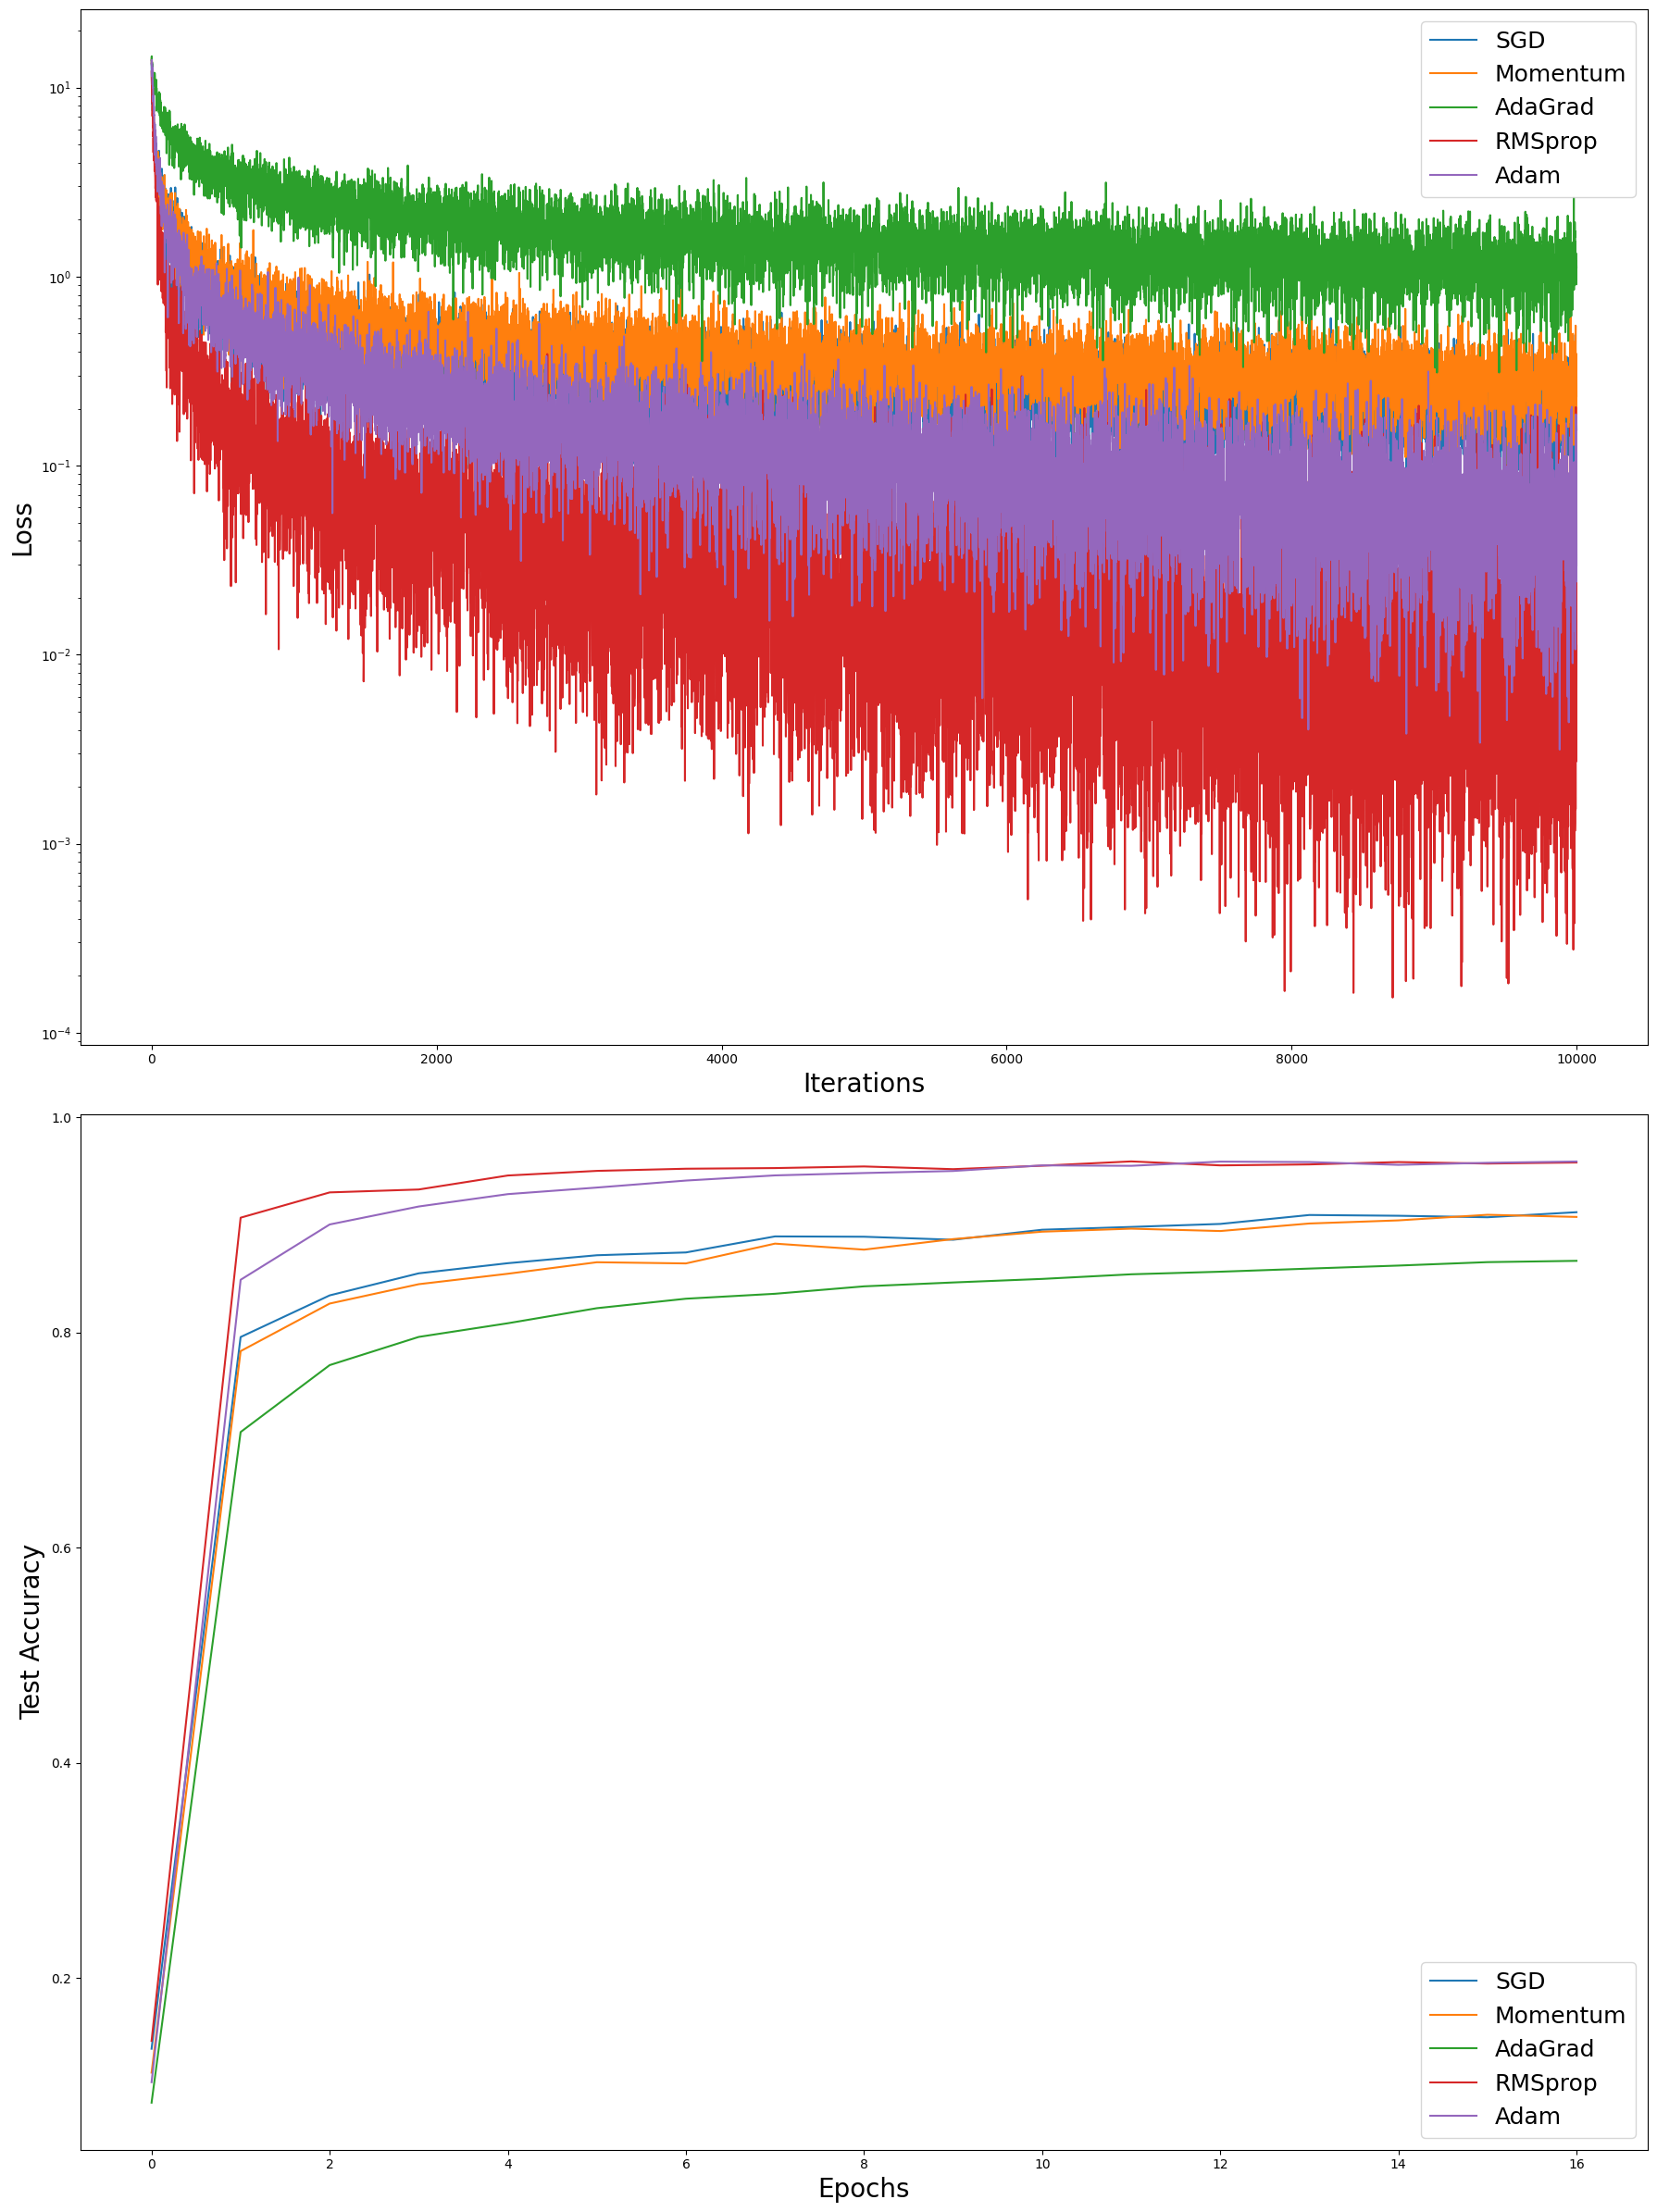

In [ ]:
if __name__ == '__main__':
    plt.figure(figsize=(18, 24))

    plt.subplot(2, 1, 1)
    for opt_name, data in results.items():
        plt.plot(data["train_loss"], label=opt_name)
    plt.xlabel("Iterations",fontsize=20)
    plt.ylabel("Loss",fontsize=20)
    plt.yscale('log')
    plt.legend(fontsize=18)

    plt.subplot(2, 1, 2)
    for opt_name, data in results.items():
        plt.plot(data["test_acc"], label=opt_name)
    plt.xlabel("Epochs",fontsize=20)
    plt.ylabel("Test Accuracy",fontsize=20)
    plt.legend(fontsize=18)

    plt.tight_layout()
    plt.show()

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;你可能已经看到了五彩斑斓的数据线条，请让我解释一下他们都是什么吧。第一张图是各个优化器参数更新过程中损失函数的变化，第二张图则是测试正确率的变化。所以你可以理解为，第一张图中下方线条的优化器更出色，第二张图上方线条的优化器更出色。值得一提的是，优化器损失函数的差别往往是指数级别的，因此为了直观对比，第一张图纵轴是取对数结果。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;这个结果有没有略微出乎你的意料？AdaGrad是表现最差的，SGD与Momentum出色些，Adam与RMSprop则是最优秀的。之所以发生这种现象，主要是因为MNIST数据集太整洁干净了，所以SGD这种简单的算法如鱼得水。而AdaGrad对梯度变化适应性强，遇到这样平坦的数据集反而难以发挥，早衰问题则是压死它的最后一根稻草。实际上，如果允许我们对SGD学习率进行精确调整，它可以做得更好。然而我们几乎无需调整Adam的超参数，它本身就已经很厉害了。这就是Adam的魅力所在。

In [ ]:
if __name__ == '__main__':
    print(best)

{'SGD': {np.float64(0.9119)}, 'Momentum': {np.float64(0.9075)}, 'AdaGrad': {np.float64(0.8667)}, 'RMSprop': {np.float64(0.9581)}, 'Adam': {np.float64(0.959)}}


#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;best字典中储存了每个优化器具体的最终测试正确率。最优秀的RMSprop与Adam的结果是大概95%，而上一章中我们最后得到的结果是约90%。加油啊用二进制说话的大哥哥！进步五个百分点已经很厉害了，但是距离100%还有另外五个百分点。我们在优化器的文章上恐怕已经走到穷途末路，从其他地方入手却还有希望，让我们进入下一小节。

### <span style="color: #dd550bff;">重要提醒！</span>
#### &nbsp;&nbsp;&nbsp;&nbsp;本章使用了大量第一章中的函数与类，所以确保import操作正常工作非常重要。请检查你下载本文档的同一目录下是否也下载了Chapter_the_first_FCNN.py，这是第一章jupyter notebook转为py文件的结果。如果没有该文件，你也可以将第一章转为py文件下载到同一目录下，具体参照jupyter notebook或VScode的下载操作。